In [38]:
! pip install numpy
! pip install pandas
! pip install matplotlib
! pip install Ipython

In [39]:
#Import Relevant Modules
import re
from datetime import datetime, date
from time import sleep
import csv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from IPython.display import clear_output
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker

In [40]:
#Retrive today's date
date = date.today()

In [41]:
def getCCSPowerData(filename, PSU_ID):
    '''
    Extract CCS power supply data from txt file

    @param:
        filename -> str
    
    @return:
        3D list of time and CCS voltage/current -> list
    '''
    
    data = []                          
    powerPattern = re.compile(r'\[(\d{2}:\d{2}:\d{2})\].*?DEBUG: Power supply ' + PSU_ID + r' readings - Voltage: (\d*.\d*)V, Current: (\d*.\d*)A', re.I)
    
    with open(filename, "r") as f:
        for line in f:
            p = powerPattern.search(line)
            if p:
                time_str = p.group(1)
                voltage = p.group(2)
                current = p.group(3)
                log_time = datetime.strptime(time_str, "%H:%M:%S").time()

                data.append((log_time, voltage, current))
    return data

In [42]:
def getHVData(filename):
    '''
    Extract pressure data from txt file

    @param:
        filename -> str
    
    @return:
        2D list of time and HV current -> list
    '''
    
    data = []                          
    pressure_pattern = re.compile(r'\[\d{4}-\d{2}-\d{2} (.*?)\] Set: (\d*) V,  HV: (\d*) V,  I: ([\d\.]*) mA', re.I)
    
    with open(filename, "r") as f:
        for line in f:
            p = pressure_pattern.search(line)
            if p:
                time_str = p.group(1)
                a0 = (float(p.group(3))/3000)*5
                a1 = (float(p.group(2))/3000)*5
                a2 = (float(p.group(4))/10)*5
                log_time = datetime.strptime(time_str, "%H:%M:%S.%f").time()

                data.append((log_time, a0, a1, a2))
    return data

In [43]:
def getCCSaTempData(filename):
    '''
    Extract CCS temperature data from txt file

    @param:
        filename -> str
    
    @return:
        2D list of Time and Pressure -> list
    '''
    
    data = []                          
    temp_pattern = re.compile(r'\[(\d{2}:\d{2}:\d{2})\].*?INFO: Unit 1 Temperature: (\d*.\d*) C', re.I)
    
    with open(filename, "r") as f:
        for line in f:
            p = temp_pattern.search(line)
            if p:
                time_str = p.group(1)
                temp = p.group(2)
                log_time = datetime.strptime(time_str, "%H:%M:%S").time()

                data.append((log_time, temp))
    return data

In [44]:
def getCCSbTempData(filename):
    '''
    Extract CCS temperature data from txt file

    @param:
        filename -> str
    
    @return:
        2D list of Time and Pressure -> list
    '''
    
    data = []                          
    temp_pattern = re.compile(r'\[(\d{2}:\d{2}:\d{2})\].*?INFO: Unit 2 Temperature: (\d*.\d*) C', re.I)
    
    with open(filename, "r") as f:
        for line in f:
            p = temp_pattern.search(line)
            if p:
                time_str = p.group(1)
                temp = p.group(2)
                log_time = datetime.strptime(time_str, "%H:%M:%S").time()

                data.append((log_time, temp))
    return data

In [45]:
def getCCScTempData(filename):
    '''
    Extract CCS temperature data from txt file

    @param:
        filename -> str
    
    @return:
        2D list of Time and Pressure -> list
    '''
    
    data = []                          
    temp_pattern = re.compile(r'\[(\d{2}:\d{2}:\d{2})\].*?INFO: Unit 3 Temperature: (\d*.\d*) C', re.I)
    
    with open(filename, "r") as f:
        for line in f:
            p = temp_pattern.search(line)
            if p:
                time_str = p.group(1)
                temp = p.group(2)
                log_time = datetime.strptime(time_str, "%H:%M:%S").time()

                data.append((log_time, temp))
    return data

In [46]:
def getPressureData(filename):
    '''
    Extract pressure data from txt file

    @param:
        filename -> str
    
    @return:
        2D list of Time and Pressure -> list
    '''
    
    data = []                          
    pressure_pattern = re.compile(r'\[(\d{2}:\d{2}:\d{2})\].*?pressure:\s*([0-9.]+E[-+]?\d+)', re.I)
    
    with open(filename, "r") as f:
        for line in f:
            p = pressure_pattern.search(line)
            if p:
                time_str = p.group(1)
                pressure = p.group(2)
                log_time = datetime.strptime(time_str, "%H:%M:%S").time()

                data.append((log_time, pressure))
    return data

In [47]:
def getPMONData(filename):
    '''
    Extract PMON Temperature data from txt file

    @param:
        filename -> str
    @return:
        list with data from each PMON
    '''
    
    data = [] 
    pmon_pattern = re.compile(r'\[(\d{2}:\d{2}:\d{2})\].*?PMON\s+temps:\s*(\{[^}]+\})', re.I)
    with open(filename, "r") as f:
        for line in f:
            p = pmon_pattern.search(line)
            if p:
                time_str = p.group(1)
                log_time = datetime.strptime(time_str, "%H:%M:%S").time()
                
                pmon_dict = eval(p.group(2))
                pmon_1 = pmon_dict[1]
                pmon_2 = pmon_dict[2]
                pmon_3 = pmon_dict[3]
                pmon_4 = pmon_dict[4]
                pmon_5 = pmon_dict[5]
                pmon_6 = pmon_dict[6]

                data.append((log_time, pmon_1, pmon_2, pmon_3, pmon_4, pmon_5, pmon_6))
    return data

In [48]:
def createCCSPowerCSV(ccs_data, psuID):
    '''

    @param:
    ccs_data: list of CCS power supply data -> list
    '''
    with open(f'ccs_psu_log-' + psuID + '-' + str(date) + '.csv', 'w', newline='') as out:
        writer = csv.writer(out)
        writer.writerow(['Time', 'Voltage (V)', 'Current (A)'])   # header
        writer.writerows(ccs_data)

    #print(f'{len(ccs_data)} rows written to ccs_psu_log-' + psuID + '-' + str(date) + '.csv')

In [49]:
def createCCSaTempCSV(pressure_data):
    '''

    @param:
    pressure_data: list of data -> list
    '''
    #Using 'w' to overwrite existing
    with open(f'CCS_A_temp_log-'+ str(date) + '.csv', 'w', newline='') as out:
        writer = csv.writer(out)
        writer.writerow(['Time', 'Temperature (C)'])   # header
        writer.writerows(pressure_data)
        
    #print(f'{len(pressure_data)} rows written to CCS_A_temp_log-'+ str(date) + '.csv')

In [50]:
def createCCSbTempCSV(pressure_data):
    '''

    @param:
    pressure_data: list of data -> list
    '''
    #Using 'w' to overwrite existing
    with open(f'CCS_B_temp_log-'+ str(date) + '.csv', 'w', newline='') as out:
        writer = csv.writer(out)
        writer.writerow(['Time', 'Temperature (C)'])   # header
        writer.writerows(pressure_data)
        
    #print(f'{len(pressure_data)} rows written to CCS_B_temp_log-'+ str(date) + '.csv')

In [51]:
def createCCScTempCSV(pressure_data):
    '''

    @param:
    pressure_data: list of data -> list
    '''
    #Using 'w' to overwrite existing
    with open(f'CCS_C_temp_log-'+ str(date) + '.csv', 'w', newline='') as out:
        writer = csv.writer(out)
        writer.writerow(['Time', 'Temperature (C)'])   # header
        writer.writerows(pressure_data)
        
    #print(f'{len(pressure_data)} rows written to CCS_C_temp_log-'+ str(date) + '.csv')

In [52]:
def createHvCSV(hv_data):
    '''

    @param:
    pressure_data: list of data -> list
    '''
    with open(f'HV_log-'+ str(date) + '.csv', 'w', newline='') as out:
        writer = csv.writer(out)
        writer.writerow(['Time', 'a0', 'a1', 'a2'])   # header
        writer.writerows(hv_data)

    #print(f'{len(hv_data)} rows written to HV_log-'+ str(date) + '.csv')

In [53]:
def createPressureCSV(pressure_data):
    '''

    @param:
    pressure_data: list of data -> list
    '''
    #Using 'w' to overwrite existing
    with open(f'pressure_log-'+ str(date) + '.csv', 'w', newline='') as out:
        writer = csv.writer(out)
        writer.writerow(['Time', 'Pressure (mbar)'])   # header
        writer.writerows(pressure_data)
        
    #print(f'{len(pressure_data)} rows written to pressure_log-'+ str(date) + '.csv')

In [54]:
def createPMONCSV(pmon_data):
    '''

    @param:
    pmon_data: list of data -> list
    '''
    with open(f'pmon_log-' + str(date) + '.csv', 'w', newline='') as out:
        writer = csv.writer(out)
        writer.writerow(['Time', 'PMON 1', 'PMON_2', 'PMON_3', 'PMON_4', 'PMON_5', 'PMON_6'])   # header
        writer.writerows(pmon_data)

    #print(f'{len(pmon_data)} rows written to pmon_log-' + str(date) + '.csv')

In [55]:
def getGraph(pmon_csv, pressure_csv, hv_csv, CCSaTemp, CCSbTemp, CCScTemp, CCSaPSU, CCSbPSU, CCScPSU, start_time='00:00:01', end_time='23:59:59'):
    '''
    Displays Graph of PMON, pressure, and HV current (beam current) using multiple panes in one graph window
    Takes 

    args:
        pmon data : list of data -> list
        pressure_data : list of data -> list
        hvCurrent_data : list of data -> list
    
    '''


    #########################################################
    # Process CCS Temperature data into a graph-able format #
    #########################################################
    CCSaTemp_result = pd.read_csv(CCSaTemp, parse_dates=['Time'])
    CCSbTemp_result = pd.read_csv(CCSbTemp, parse_dates=['Time'])
    CCScTemp_result = pd.read_csv(CCScTemp, parse_dates=['Time'])

    # Filter by time range
    filtered_ccsA_temp = CCSaTemp_result[(CCSaTemp_result['Time'] >= start_time) & (CCSaTemp_result['Time'] <= end_time)]
    filtered_ccsB_temp = CCSbTemp_result[(CCSbTemp_result['Time'] >= start_time) & (CCSbTemp_result['Time'] <= end_time)]
    filtered_ccsC_temp = CCScTemp_result[(CCScTemp_result['Time'] >= start_time) & (CCScTemp_result['Time'] <= end_time)]

    #########################################################
    # Process CCS PSU data into a graph-able format #
    #########################################################
    CCSaPSU_result = pd.read_csv(CCSaPSU, parse_dates=['Time'])
    CCSbPSU_result = pd.read_csv(CCSbPSU, parse_dates=['Time'])
    CCScPSU_result = pd.read_csv(CCScPSU, parse_dates=['Time'])

    # Filter by time range
    filtered_CCSaPSU = CCSaPSU_result[(CCSaPSU_result['Time'] >= start_time) & (CCSaPSU_result['Time'] <= end_time)]
    filtered_CCSbPSU = CCSbPSU_result[(CCSbPSU_result['Time'] >= start_time) & (CCSbPSU_result['Time'] <= end_time)]
    filtered_CCScPSU = CCScPSU_result[(CCScPSU_result['Time'] >= start_time) & (CCScPSU_result['Time'] <= end_time)]


    ####################################################
    # Process HV current data into a graph-able format #
    ####################################################

    current_result = pd.read_csv(hv_csv, parse_dates=['Time'])

    # Filter by time range
    filtered_current = current_result[(current_result['Time'] >= start_time) & (current_result['Time'] <= end_time)]


    ###################
    # Graph the data! #
    ###################

    # Set graph details, including figure aspect ratio and graph height ratios
    fig, axs = plt.subplots(4, 1, figsize=(16, 9), sharex=True)

    # # --- PMON plot ---
    # for key in ports.values():
    #     if(time.size == len(pmon_data[key])) :
    #         axs[0].plot(time, pmon_data[key], label=key)
    # axs[0].set_ylabel('PMON Temperatures')
    # axs[0].legend(loc='upper left')
    # axs[0].grid(True)

    # CCS Temperature plot
    axs[0].plot(filtered_ccsA_temp['Time'].to_numpy(), filtered_ccsA_temp['Temperature (C)'].to_numpy(), label='CCS A')
    axs[0].plot(filtered_ccsB_temp['Time'].to_numpy(), filtered_ccsB_temp['Temperature (C)'].to_numpy(), label='CCS B')
    axs[0].plot(filtered_ccsC_temp['Time'].to_numpy(), filtered_ccsC_temp['Temperature (C)'].to_numpy(), label='CCS C')
    axs[0].set_ylabel('CCS Temperatures')
    axs[0].legend(loc='upper left')
    

    # # --- Pressure plot ---
    # axs[2].plot(filtered_pressure['Time'].to_numpy(), filtered_pressure['Pressure (mbar)'].to_numpy())
    # axs[2].set_ylabel('Pressure (mbar)')
    # axs[2].grid(True)

    # --- HV monitor plot ---
    axs[1].plot(filtered_current['Time'].to_numpy(), filtered_current['a0'].to_numpy())
    axs[1].plot(filtered_current['Time'].to_numpy(), filtered_current['a1'].to_numpy())
    axs[1].plot(filtered_current['Time'].to_numpy(), filtered_current['a2'].to_numpy())
    axs[1].set_ylabel('HV monitor voltages')
    axs[1].grid(True)

    # CCS voltage plot
    axs[2].plot(filtered_CCSaPSU['Time'].to_numpy(), filtered_CCSaPSU['Voltage (V)'].to_numpy(), label='CCS A')
    axs[2].plot(filtered_CCSbPSU['Time'].to_numpy(), filtered_CCSbPSU['Voltage (V)'].to_numpy(), label='CCS B')
    axs[2].plot(filtered_CCScPSU['Time'].to_numpy(), filtered_CCScPSU['Voltage (V)'].to_numpy(), label='CCS C')
    axs[2].set_ylabel('CCS Voltages')
    axs[2].legend(loc='upper left')

    # CCS current plot
    axs[3].plot(filtered_CCSaPSU['Time'].to_numpy(), filtered_CCSaPSU['Current (A)'].to_numpy(), label='CCS A')
    axs[3].plot(filtered_CCSbPSU['Time'].to_numpy(), filtered_CCSbPSU['Current (A)'].to_numpy(), label='CCS B')
    axs[3].plot(filtered_CCScPSU['Time'].to_numpy(), filtered_CCScPSU['Current (A)'].to_numpy(), label='CCS C')
    axs[3].set_ylabel('CCS Currents')
    axs[3].legend(loc='upper left')

    # Format x-axis to show only the time (HH:MM)
    time_format = mdates.DateFormatter('%H:%M:%S')
    axs[3].xaxis.set_major_formatter(time_format)


    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


C:\Users\Ian\AppData\Local\Temp\ipykernel_5724\2127674916.py:43: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  current_result = pd.read_csv(hv_csv, parse_dates=['Time'])


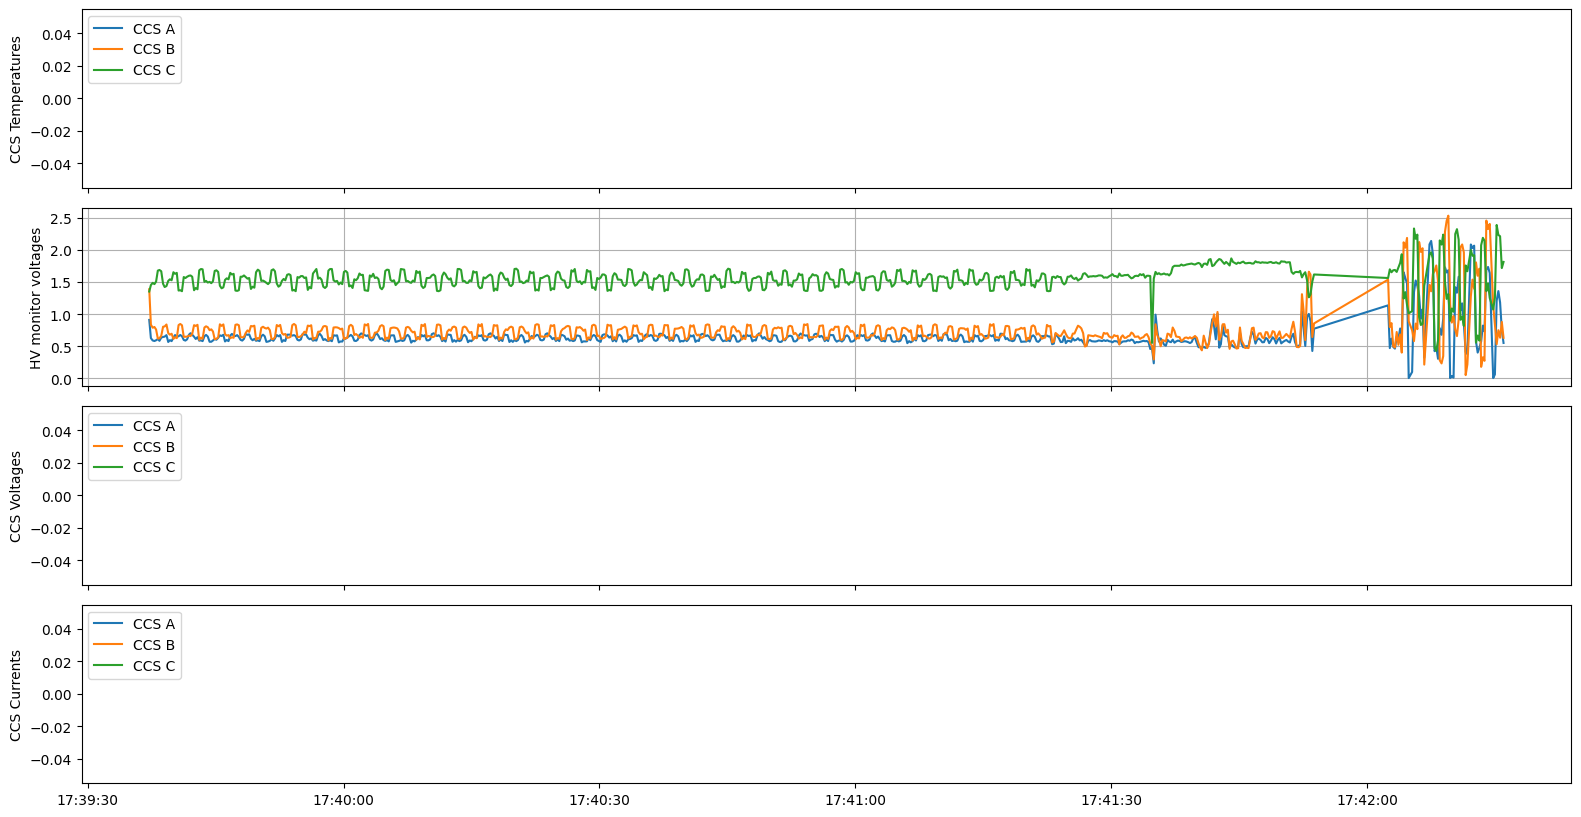

In [56]:
# Log file location on laptop: 'C:/Users/Experiment/EBEAM_dashboard/EBEAM-Dashboard-Logs/'
# Tera term log file location on laptop: 'C:/Users/Experiment/cbmark_logger/Tera Term logs'

# Enter your Ebeam dashboard and Tera Term log files here and comment out the following 4 lines to use a specific file
dashboard_log_file = 'Data samples//log_export_2025-05-29_14-31-19.txt'
teraTerm_log_file = 'Data samples/HV_monitor 2025-06-10.txt'

# # Pick the most recently edited Tera Term log file
# teraTerm_files = glob.glob("C:/Users/Experiment/cbmark_logger/Tera Term logs/*")
# teraTerm_log_file = max(teraTerm_files, key=os.path.getctime)

# # Pick the most recently edited dashboard log file
# dashboard_files = glob.glob("C:/Users/Experiment/EBEAM_dashboard/EBEAM-Dashboard-Logs/*")
# dashboard_log_file = max(dashboard_files, key=os.path.getctime)

# If you want to use a CSV that wasn't generated right now, you'll need to change these
pmon_csv = f'pmon_log-' + str(date) + '.csv'
pressure_csv = f'pressure_log-'+ str(date) + '.csv'
hvCurrent_csv = f'HV_log-'+ str(date) + '.csv'
CCSaTemp = f'CCS_A_temp_log-'+ str(date) + '.csv'
CCSbTemp = f'CCS_A_temp_log-'+ str(date) + '.csv'
CCScTemp = f'CCS_A_temp_log-'+ str(date) + '.csv'
CCSaPSU = f'ccs_psu_log-' + '1' + '-' + str(date) + '.csv'
CCSbPSU = f'ccs_psu_log-' + '2' + '-' + str(date) + '.csv'
CCScPSU = f'ccs_psu_log-' + '3' + '-' + str(date) + '.csv'

# Create the CSV files
# createPMONCSV(getPMONData(dashboard_log_file))
# createPressureCSV(getPressureData(dashboard_log_file))
createHvCSV(getHVData(teraTerm_log_file))
createCCSaTempCSV(getCCSaTempData(dashboard_log_file))
createCCSbTempCSV(getCCSbTempData(dashboard_log_file))
createCCScTempCSV(getCCScTempData(dashboard_log_file))
createCCSPowerCSV(getCCSPowerData(dashboard_log_file, '1'), '1')
createCCSPowerCSV(getCCSPowerData(dashboard_log_file, '2'), '2')
createCCSPowerCSV(getCCSPowerData(dashboard_log_file, '3'), '3')

# Call the function to generate the graph
getGraph(pmon_csv, pressure_csv, hvCurrent_csv, CCSaTemp, CCSbTemp, CCScTemp, CCSaPSU, CCSbPSU, CCScPSU)




C:\Users\Ian\AppData\Local\Temp\ipykernel_5724\2127674916.py:43: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  current_result = pd.read_csv(hv_csv, parse_dates=['Time'])


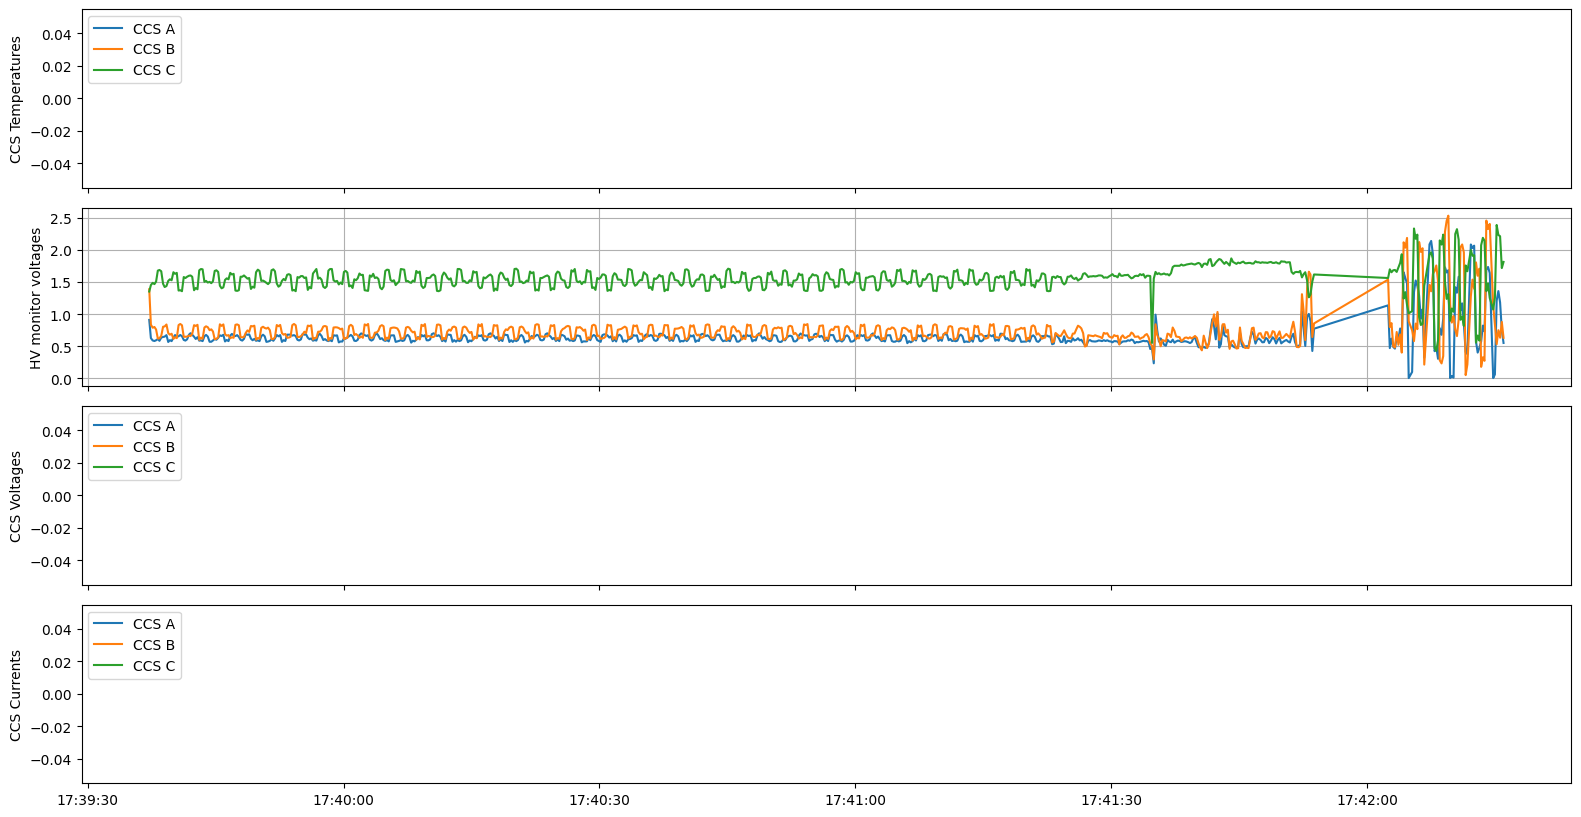

KeyboardInterrupt: 

In [57]:
# Log file location on laptop: 'C:/Users/Experiment/EBEAM_dashboard/EBEAM-Dashboard-Logs/'
# Tera term log file location on laptop: 'C:/Users/Experiment/cbmark_logger/Tera Term logs'

# Enter your Ebeam dashboard and Tera Term log files here and comment out the following 4 lines to use a specific file
dashboard_log_file = 'Data samples//log_export_2025-05-29_14-31-19.txt'
teraTerm_log_file = 'Data samples/HV_monitor 2025-06-10.txt'

while 1 :
    # # Pick the most recently edited Tera Term log file
    # teraTerm_files = glob.glob("C:/Users/Experiment/cbmark_logger/Tera Term logs/*")
    # teraTerm_log_file = max(teraTerm_files, key=os.path.getctime)

    # # Pick the most recently edited dashboard log file
    # dashboard_files = glob.glob("C:/Users/Experiment/EBEAM_dashboard/EBEAM-Dashboard-Logs/*")
    # dashboard_log_file = max(dashboard_files, key=os.path.getctime)

    # If you want to use a CSV that wasn't generated right now, you'll need to change these
    pmon_csv = f'pmon_log-' + str(date) + '.csv'
    pressure_csv = f'pressure_log-'+ str(date) + '.csv'
    hvCurrent_csv = f'HV_log-'+ str(date) + '.csv'
    CCSaTemp = f'CCS_A_temp_log-'+ str(date) + '.csv'
    CCSbTemp = f'CCS_A_temp_log-'+ str(date) + '.csv'
    CCScTemp = f'CCS_A_temp_log-'+ str(date) + '.csv'
    CCSaPSU = f'ccs_psu_log-' + '1' + '-' + str(date) + '.csv'
    CCSbPSU = f'ccs_psu_log-' + '2' + '-' + str(date) + '.csv'
    CCScPSU = f'ccs_psu_log-' + '3' + '-' + str(date) + '.csv'

    # Create the CSV files
    # createPMONCSV(getPMONData(dashboard_log_file))
    # createPressureCSV(getPressureData(dashboard_log_file))
    createHvCSV(getHVData(teraTerm_log_file))
    createCCSaTempCSV(getCCSaTempData(dashboard_log_file))
    createCCSbTempCSV(getCCSbTempData(dashboard_log_file))
    createCCScTempCSV(getCCScTempData(dashboard_log_file))
    createCCSPowerCSV(getCCSPowerData(dashboard_log_file, '1'), '1')
    createCCSPowerCSV(getCCSPowerData(dashboard_log_file, '2'), '2')
    createCCSPowerCSV(getCCSPowerData(dashboard_log_file, '3'), '3')

    # Call the function to generate the graph
    getGraph(pmon_csv, pressure_csv, hvCurrent_csv, CCSaTemp, CCSbTemp, CCScTemp, CCSaPSU, CCSbPSU, CCScPSU)
    sleep(5)
    clear_output(True)